<a href="https://colab.research.google.com/github/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento/blob/main/MVP_Sprint_2_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Barbosa Leite Silva

**Matrícula:** 4052025002093

**Dataset:** [Marketing bancário](https://archive.ics.uci.edu/dataset/222/bank+marketing)

# Descrição do Problema

Os dados referem-se a campanhas de marketing direto (chamadas telefônicas) de uma instituição bancária portuguesa. O objetivo da classificação é prever se o cliente irá se inscrever em um depósito a prazo (variável result).

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?
2. Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?
3. Ligar mais vezes para um cliente diminui a chance dele contratar?
4. Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características, (como idade, número de ligações, dias entre as ligações, ocupação e nível de escolaridade), o objetivo é prever qual o resultado final do contato (yes/no ).

## Seleção de Dados

O dataset Bank Marketing é um dataset disponível no UCI Machine Learning Repository. Os dados referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing baseavam-se em chamadas telefónicas. Frequentemente, era necessário mais do que um contacto com o mesmo cliente para apurar se o produto (depósito a prazo bancário) seria contratado ("sim") ou não ("não"). O dataset é composto por 45211 instâncias e 17 colunas.

## Atributos do Dataset

O dataset Bank Marketing contém 41188 amostras, cada uma com 17 atributos (16 features e 1 target):

| Variável | Descrição | Tipo | Categorias |
|---       | ---       | ---  | ---        |
| **age**  | idade     | numérica | N/A    |
| **job**  | ocupação  | categórica | admin., blue-collar, entrepneur housemaid, management, retired, self-employed, services, student, <br>technician, unemployed, unknown |
| **marital** | situação conjugal | categórica | maried, single, divorced* unknown|
| **education** | nível de educação	| categórica | basic.4y, bac.6y,  basic.9y, high.school, illiterate, professional.course, university.degree, unknown |
| **default** | já entrou em incumprimento financeiro no passado?  | binária | yes/no |
| **balance** | saldo médio anual, em euros | numérica | N/A |
| **housing** | possui empréstimo imobiário?  | binária | yes/no |
| **loan** | possui empréstimo pessoal?  | binária | yes/no |
| **contact** | tipo de contato | categórica | celular, telefone |
| **day_of_week** | último dia de contato da semana  | numérica | N/A |
| **month** | mês do último contato | categórica | jan, fev, mar ... nov, dez |
| **duration** | duração do último contato, em segundos** |  numérico | N/A |  
| **campaign** | número de contatos realizados durante esta campanha para este cliente (inclui o último contato) | numérico | N/A |
| **pdays** | dias de folga: Número de dias decorridos desde o último contato com o  cliente em uma <br> campanha anterior.*** | numérico | N/A |
| **previous** | número de contatos realizados antes desta campanha para  este cliente. | numérica | N/A |
| **poutcome** | resultado da campanha de marketing anterior | categórica  | fracasso, inexistente, sucesso |
| **result** | O cliente subscreveu um depósito prazo  | binária | yes/no |

\* Nota 1: divorcidado refere-se tanto a pessoas divorciadas, quanto a pessoas viúvas.

** Nota 2: o atributo duração afeta significativamente o resultado esperado (por exemplo, se a duração for igual a 0, então y = 'não').

*** Nota 3: -1 significa que o cliente não foi contatado anteriormente.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Bank Marketing.

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo
from matplotlib import colors

In [3]:
# carregamento do dataset
bank_marketing = fetch_ucirepo(id=222)

In [4]:
# guardo o dataset em um dataframe
df = bank_marketing.data.features
df['result'] = bank_marketing.data.targets

In [5]:
# primeiras linhas
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,result
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Bank Marketing, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

A seguir apresentamos uma análise inicial dos dados do dataset:

In [6]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 45211

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  result       45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


Como podemos ver, algumas das colunas possuem valores nulos. Com algumas análises, poderemos verificar qual a melhor abordagem para tratar esses valores.

## Distribuição das categorias

In [7]:
df.groupby('result', dropna=False).size()

,0
result,
no,39922
yes,5289


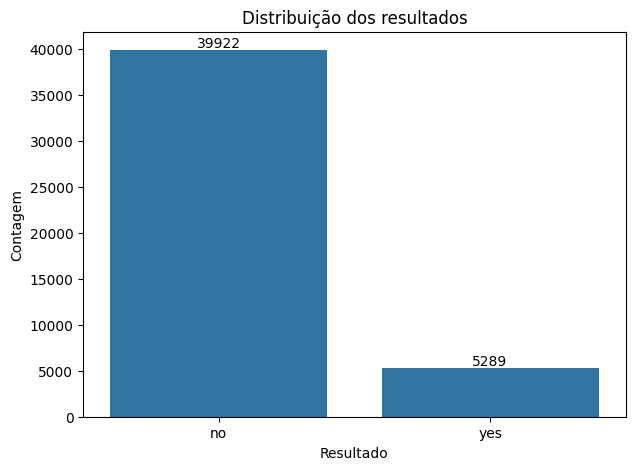

In [8]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
df['result'] = df['result'].fillna('NaN')
axes = sns.countplot(x='result', data=df)
plt.title('Distribuição dos resultados')
plt.xlabel('Resultado')
plt.ylabel('Contagem')
plt.bar_label(axes.containers[0])
plt.show()

O gráfico de barras mostra um desbalanceamento entre as categorias. Enquanto cerca de 5 mil (12%) são registros de casos bem-sucedidos, 40 mil (88%) são registros de casos mal-sucedidos. Na etapa de pré-processamento iremos verificar a melhor forma de diminuir essa diferença.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [9]:
# estatísticas descritivas básicas do dataset
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Análise inicial:**
- **age**: os valores de idade parecem estar dentro de uma distribuição esperada, com valores mínimos e máximos dentro do esperado.
- **balance**: o balanço médio anual apresenta uma amplitude de valores (min: -8019 e max: 102127). Embora, sejam valores significativos, não necessariamente são outliers, indicando que o banco buscou abordar diferentes tipos de clientes.
- **day_of_week**: embora a descrição dê a entender que sejam dias da semana (ou seja, entre 1 e 7), as variáveis demonstram que são dias do mês, entre 1 e 31.
- **duration**: embora represente o tempo em segundos, o valor máximo ser de 4918 (81 minutos) provavelmente indica um outiler.
- **campaign**: não temos a informação de quanto tempo durou a campanha, mas pelas informações descritivas (média, desvio padrão e mediana), o valor máximo de 63 ligações pode representar um outlier.
- **pdays**: dias de folga, desde o último contato. O valor -1 indica que não que o cliente não foi contatado anteriormente. Um ponto de atenção é que pelo menos 75% do conjunto de dados é composto de -1, indicando que a grande maioria dos contatos foram feitos pela primeira vez. Além disso, o valor máximo de 871 é um provável outlier, pois é valor muito discrepante dos demais valores da distribuição.
- **previous**: número de contatos realizados antes dessa campanha. As informações apresentadas demonstram que pelo menos 75% do conjunto de clientes nunca foi contatado em campanhas anteriores. Desse modo, o valor máximo de 275 também pode representar um outlier.

## *Análise das variáveis*
Além das medidas descritivas, é importante analisar a **distribuição dos dados**. Esta análise é crucial, pois permite um melhor entendimento dos dados, revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers).

Dentre os principais gráficos para realizar esta análise destacam-se o **histograma**, **gráfico de barras** e o **boxplot**. O *histograma* é utilizado para avaliar variáveis contínuas, representando a distribuição dos dados, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

O *gráfico de barras*, por sua vez, permite contar a quantidade de observações por variável categórica e realizar análises como comparação, contagem, rankeamento.

Já o *boxplot* é amplamente utilizado quando queremos comparar diferentes distribuições. Ele permite analisar quartis, medianas e outliers por variável.

A seguir traremos a análise de cada uma das variáveis do dataset.

### age (idade)

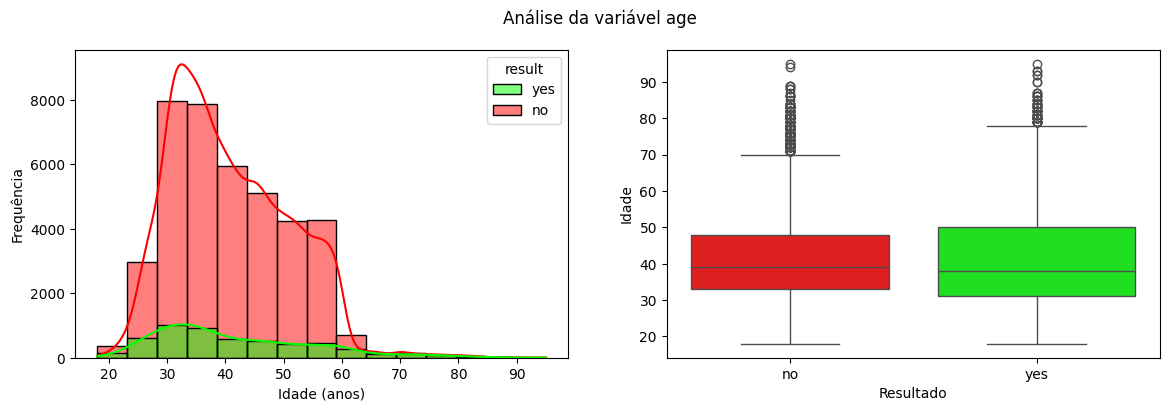

In [10]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável age')

sns.histplot(data=df, kde=True, binwidth=5, x='age', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Idade (anos)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='age', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Idade')
plt.show()

In [11]:
print("Valores nulos:", df['age'].isnull().sum())

Valores nulos: 0


Como observado na figura, podemos dizer que há uma distribuilção assimétrica à direita.

A grande diferença entre casos negativos e casos positivos, acaba dificultando uma análise clara das curvas de comportamento. Após a etapa de pré-processamento, poderá ser observado melhor a influência dessa variável com relação ao resultado da campanha.

No entanto, a priori, podemos dizer que não há uma distinção tão evidente no formato da curva dos que negaram o contrato, para os que aceitaram o contrato.

Embora o gráfico de boxplot evidencie outliers, observa-se que os valores apresentados estão dentro dos limites consideráveis de tempo de vida humana, ou seja, seriam outliers naturais. Por fim, observa-se que não há valores nulos.

### job (ocupação)

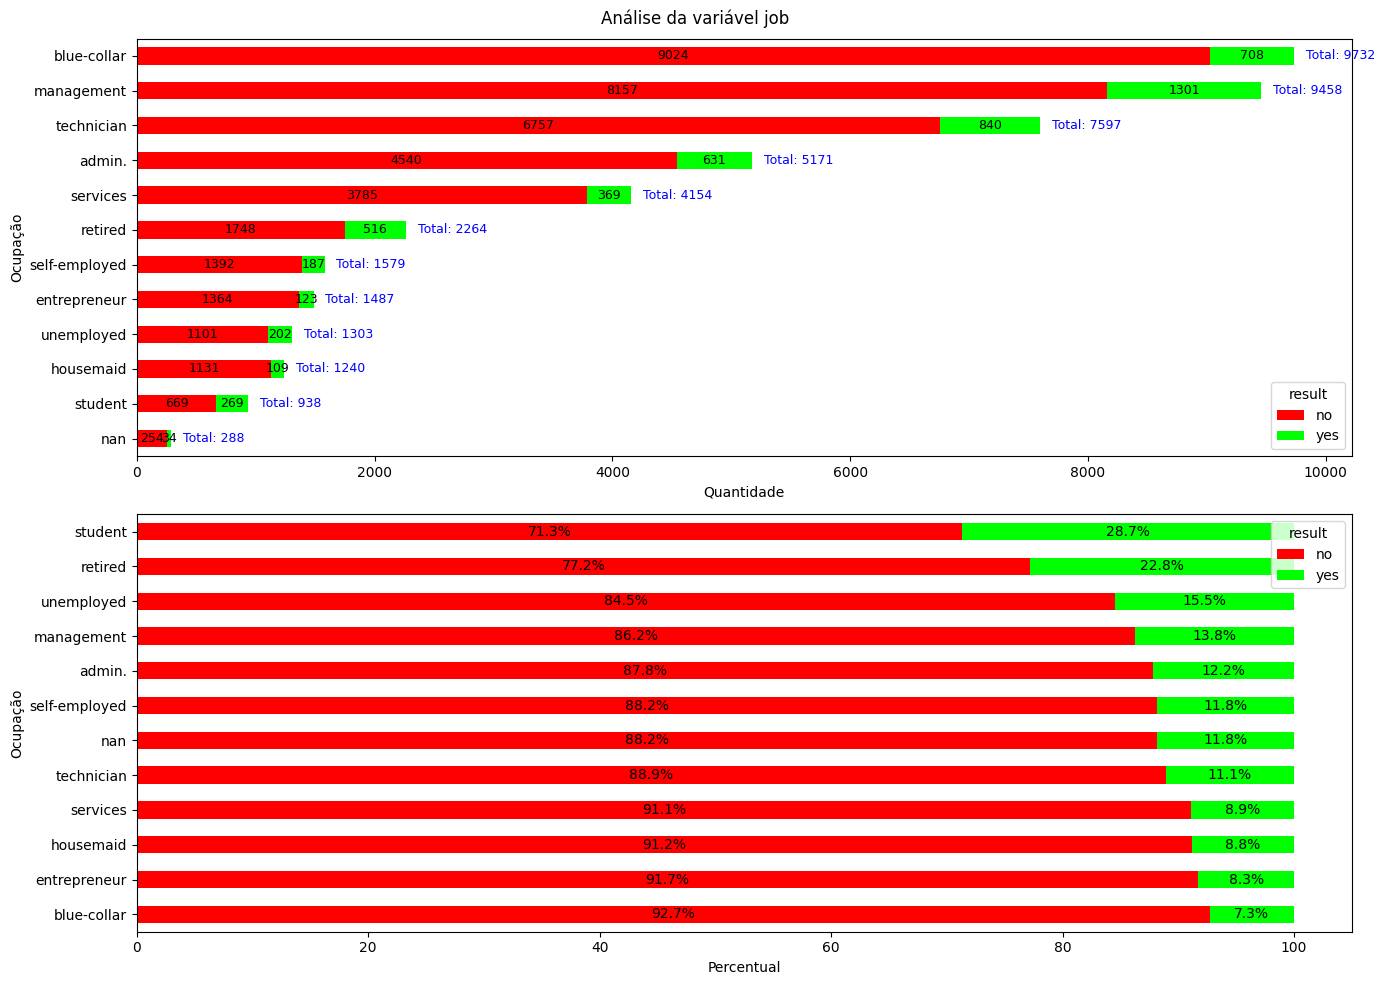

In [12]:
fig, ax = plt.subplots(2,1, figsize = (14, 10))
fig.suptitle('Análise da variável job')

# plot 1
# Preparação do df
df_group = df.groupby(['job', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('job', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='job', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get)

# plot
df_pivot.plot(kind='barh', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Quantidade')
ax[0].set_ylabel('Ocupação')

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(no/2, i, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(no + yes/2, i, f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(no+yes+100, i, f"Total: {no+yes}", va='center', ha='left', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('job', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='job', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=True)

# plot
df_pivot.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Percentual')
ax[1].set_ylabel('Ocupação')

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(no/2, i, f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [13]:
print("Valores nulos:", df['job'].isnull().sum())

Valores nulos: 288


Novamente, o desbalanceamento do dataset acaba dificultando a análise pura da quantidade de ocorrências por ocupação. Por esse motivo, um segundo gráfico foi apresentado, para analisar o percentual de aceite da campanha por ocupação.

Com isso, observamos que a ocupação 'blue-collar' foi a mais contatada, seguida pelo 'management' e 'technician'. Mas as ocupações com maior taxa de aceitação foi 'student' (quase 30% de aceitação), 'retired' (22%) e 'unemployed' (15%). Blue-collar, a ocupação mais contatada, foi a de menor taxa de aceitação (7%).

Por fim, observa-se a presença de 288 registros nulos.

### marital (estado civil)

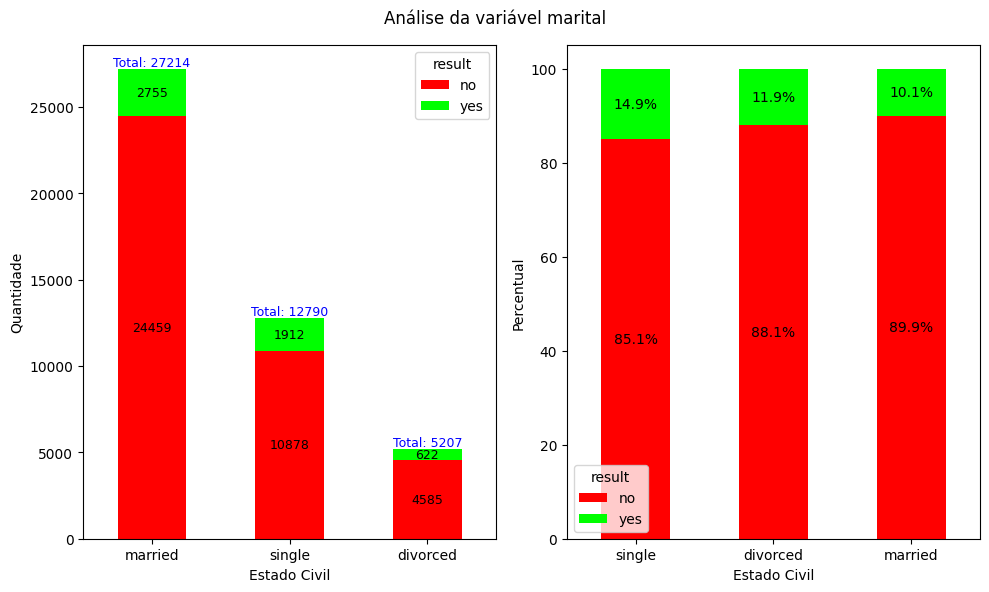

In [14]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável marital')

# plot 1
# Preparação do df
df_group = df.groupby(['marital', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('marital', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='marital', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Estado Civil')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('marital', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='marital', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Estado Civil')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [15]:
print("Valores nulos:", df['marital'].isnull().sum())

Valores nulos: 0


Embora haja uma diferença significativa de quantidade de registros de cada estado civil, a diferença entre os valores percentuais não é tão discrepante, indicando que essa variável, possivelmente, não influencia tanto no resultado. Por fim, observa-se que não há registros nulos.

### education (nível de escolaridade)

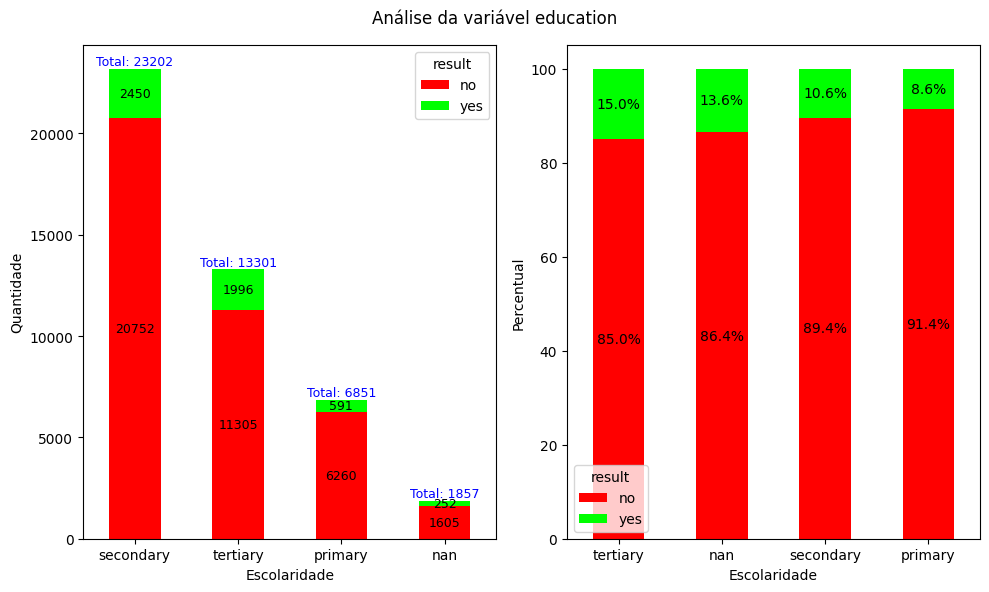

In [16]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável education')

# plot 1
# Preparação do df
df_group = df.groupby(['education', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('education', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='education', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Escolaridade')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('education', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='education', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Escolaridade')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [17]:
print("Valores nulos:", df['education'].isnull().sum())

Valores nulos: 1857


Embora o nível 'secondary' tenha sido o mais contatado, o 'tertiary' foi de maior taxa de aceitação. No entanto, a diferença percentual entre as categorias ainda não seja tão significativa. Por fim, observa-se a presença de 1857 registros nulos.

### default (incumprimento financeiro no passado?)

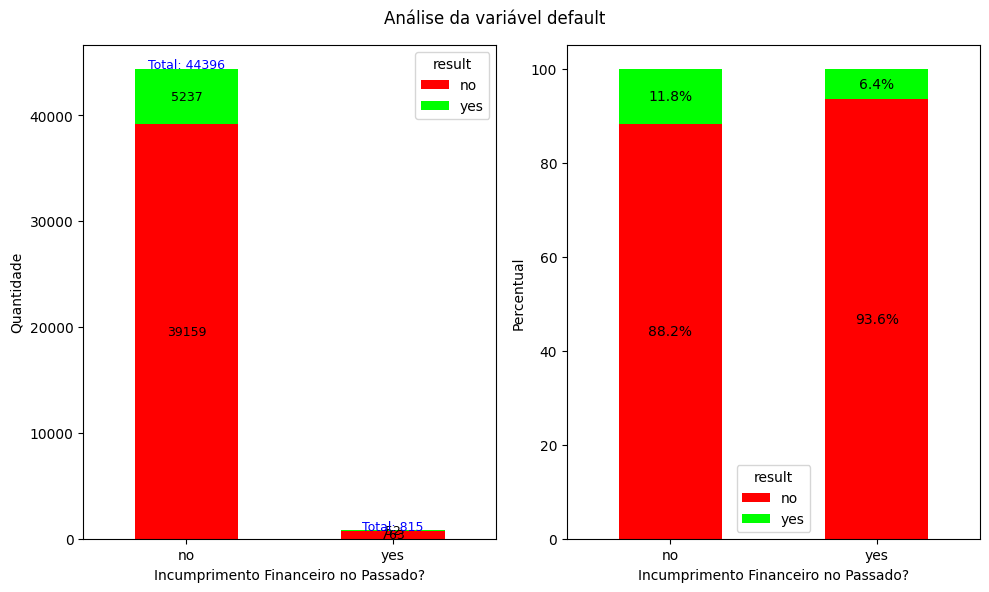

In [18]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável default')

# plot 1
# Preparação do df
df_group = df.groupby(['default', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('default', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='default', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Incumprimento Financeiro no Passado?')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('default', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='default', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Incumprimento Financeiro no Passado?')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [19]:
print("Valores nulos:", df['default'].isnull().sum())

Valores nulos: 0


In [20]:
df_group

,default,result,size,total,percent
0,no,no,39159,44396,88.203892
1,no,yes,5237,44396,11.796108
2,yes,no,763,815,93.619632
3,yes,yes,52,815,6.380368


Observamos uma diferença imensa entre a quantidade de pessoas em incumprimento finaceiro (44396) e as que não estão (815). Dessa forma fica difícil avaliar a relevância dessa variável. Em termos percentuais, não há uma diferença significativa. Por fim, observa-se que não há registros nulos.

### balance (saldo médio anual)

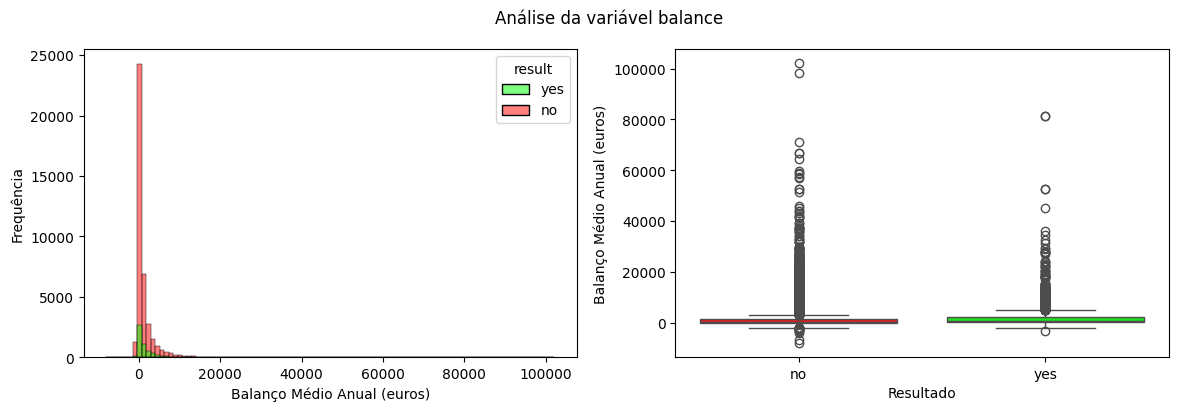

In [21]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável balance')

sns.histplot(data=df, bins=100, x='balance', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Balanço Médio Anual (euros)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='balance', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Balanço Médio Anual (euros)')
plt.show()

In [22]:
print("Valores nulos:", df['balance'].isnull().sum())

Valores nulos: 0


A variável foi divida em faixa de valores para facilitar a visualização. Vários intervalos foram testados, até chegar no número de 100 bins. A distribuição pode ser considerada assimétrica à direita. Observa-se a presença de outliers, pois uma quantidade ínfima de clientes passa do balanço médio de 20 mil ao ano. Isso pode representar um outlier natural, pois pode haver rendas discrepantes, no entanto precisará ser tratado na etapa de pré-processamento.

A presença desses outliers e o desbalanceamento prejudicaram uma melhor visualização da distribuição. Mas, a priori, o gráfico boxplot não indica uma diferença significativa entre as pessoas que aderiram a campanha. Por fim, observa-se que não há presença de valores nulos.

### housing (possui empréstimo imobiário?)

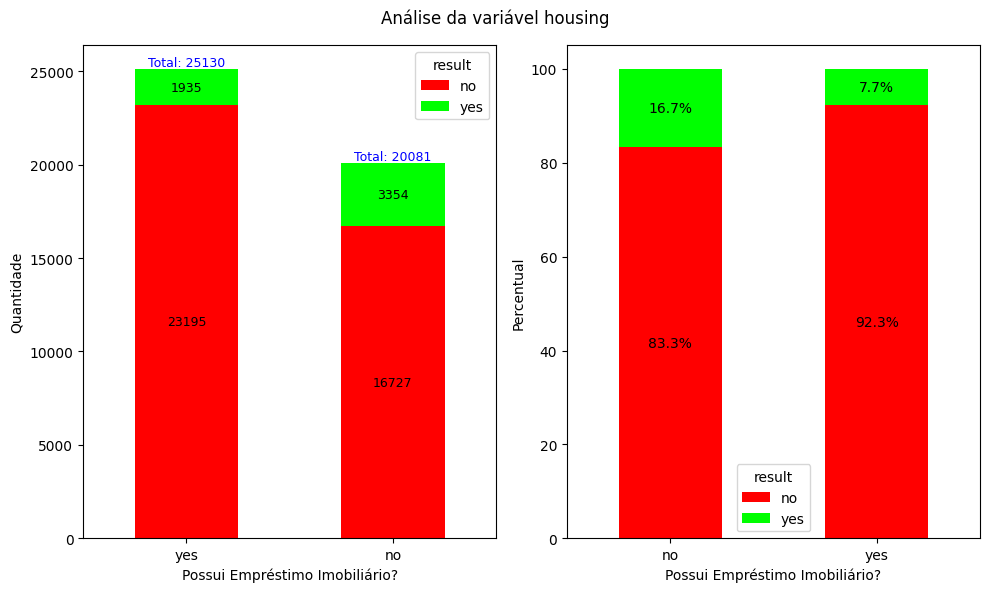

In [23]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável housing')

# plot 1
# Preparação do df
df_group = df.groupby(['housing', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('housing', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='housing', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Possui Empréstimo Imobiliário?')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('housing', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='housing', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Possui Empréstimo Imobiliário?')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [24]:
print("Valores nulos:", df['housing'].isnull().sum())

Valores nulos: 0


Esta variável possui um desbalanceamento menos expressivo. Foram contactados cerca de 25 mil clientes que possuiam empréstimo imobiliário, e cerca de 20 mil que não possuiam. Embora a diferença percentual entre as categorias não seja tão significativa, a taxa de adesão à campanha foi maior entre os que não possuiam empréstimo imobiliário. Por fim, observa-se que não há presença de valores nulos.

### loan (possui empréstimo pessoal?)

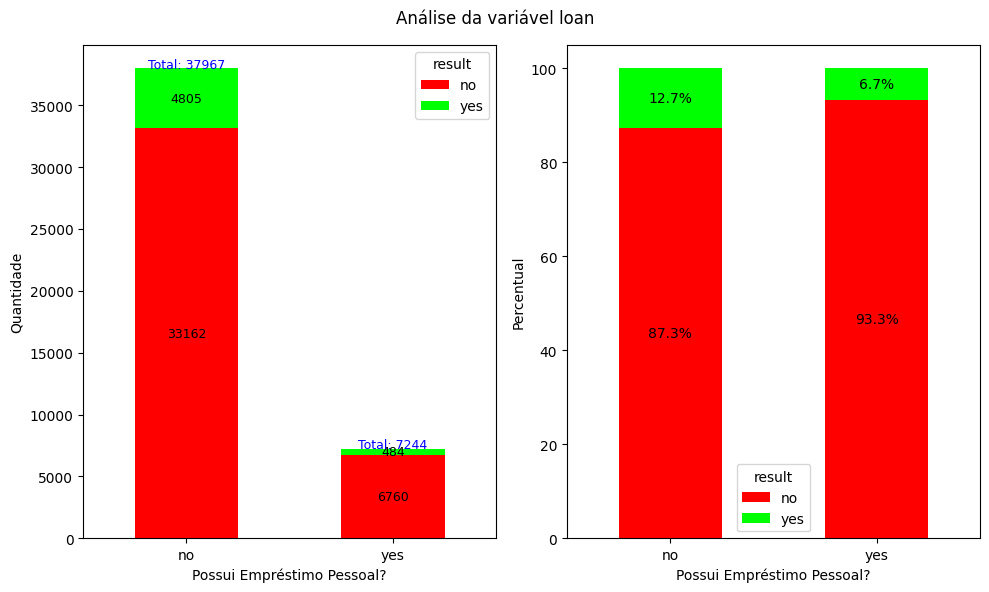

In [25]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável loan')

# plot 1
# Preparação do df
df_group = df.groupby(['loan', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('loan', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='loan', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Possui Empréstimo Pessoal?')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('loan', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='loan', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Possui Empréstimo Pessoal?')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [26]:
print("Valores nulos:", df['loan'].isnull().sum())

Valores nulos: 0


Há uma quantidade significativa maior de clientes sem empréstimo pessoal, do que os com  empréstimo pessoal. Esse desbalanceamento prejudica a análise. Percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, não há presença de valores nulos.

### contact (tipo de contato)

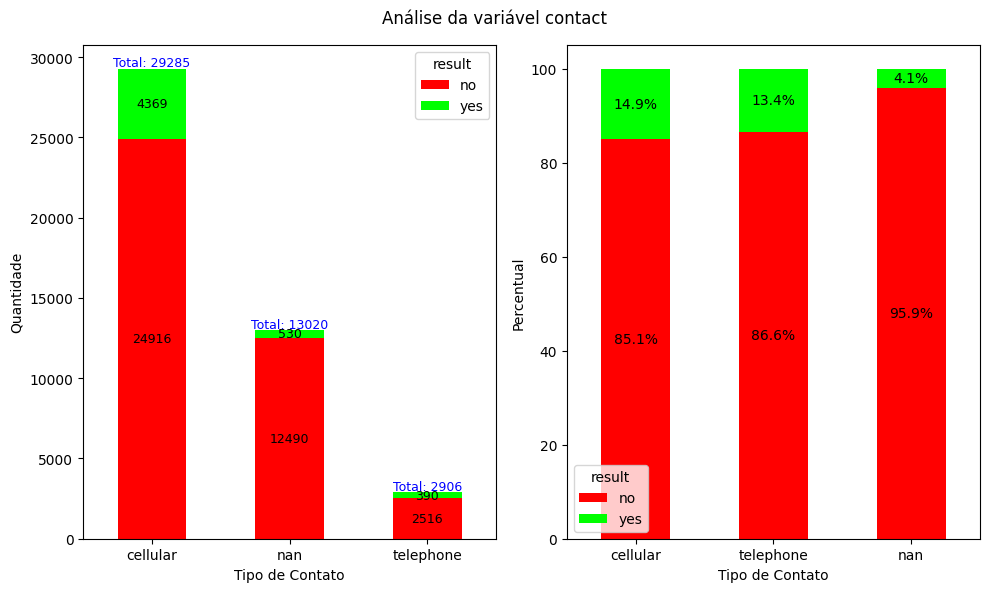

In [27]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável contact')

# plot 1
# Preparação do df
df_group = df.groupby(['contact', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('contact', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='contact', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Tipo de Contato')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('contact', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='contact', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Tipo de Contato')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [28]:
print("Valores nulos:", df['contact'].isnull().sum())

Valores nulos: 13020


Há uma quantidade significativa maior de clientes contactados via celular (29096) sem empréstimo pessoal, do que os com empréstimo pessoal. Esse desbalanceamento prejudica a análise. Apesar disso, percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, observa-se que há 13020 registros sem a informação do tipo de contato realizado.

### day_of_week (último dia de contato)

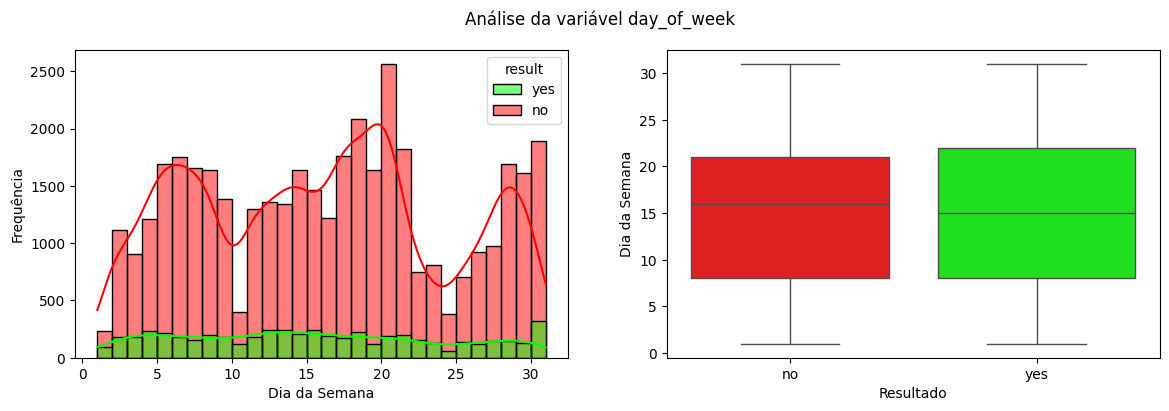

In [29]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável day_of_week')

sns.histplot(data=df, kde=True, binwidth=1, x='day_of_week', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Dia da Semana')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='day_of_week', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Dia da Semana')

plt.show()

In [30]:
print("Valores nulos:", df['day_of_week'].isnull().sum())

Valores nulos: 0


A distribuição apresentada está mais próxima de uma distribuição multimodal.

Do mesmo modo que a variável anterior, a diferença no número de registros de cada classe, acaba dificultando uma análise mais acertiva.

Outro ponto importante a se observar é que o nome da variável não condiz com os valores da distribuição. O nome da variável dá a entender que o valor representa o dia da semana, que deveria variar entre segunda a domingo. Mas os valores apresentados, na verdade, se referem ao dia do mês em que foi feito o contato. Isso seria interessante, se buscarmos entender o comportamento ao longo do mês, mas se a análise for feita por dia da semana, é necessário agrupar esses valores por dia da semana.

Por fim, observa-se que não há presença de valores nulos.

### month (mês do último contato)

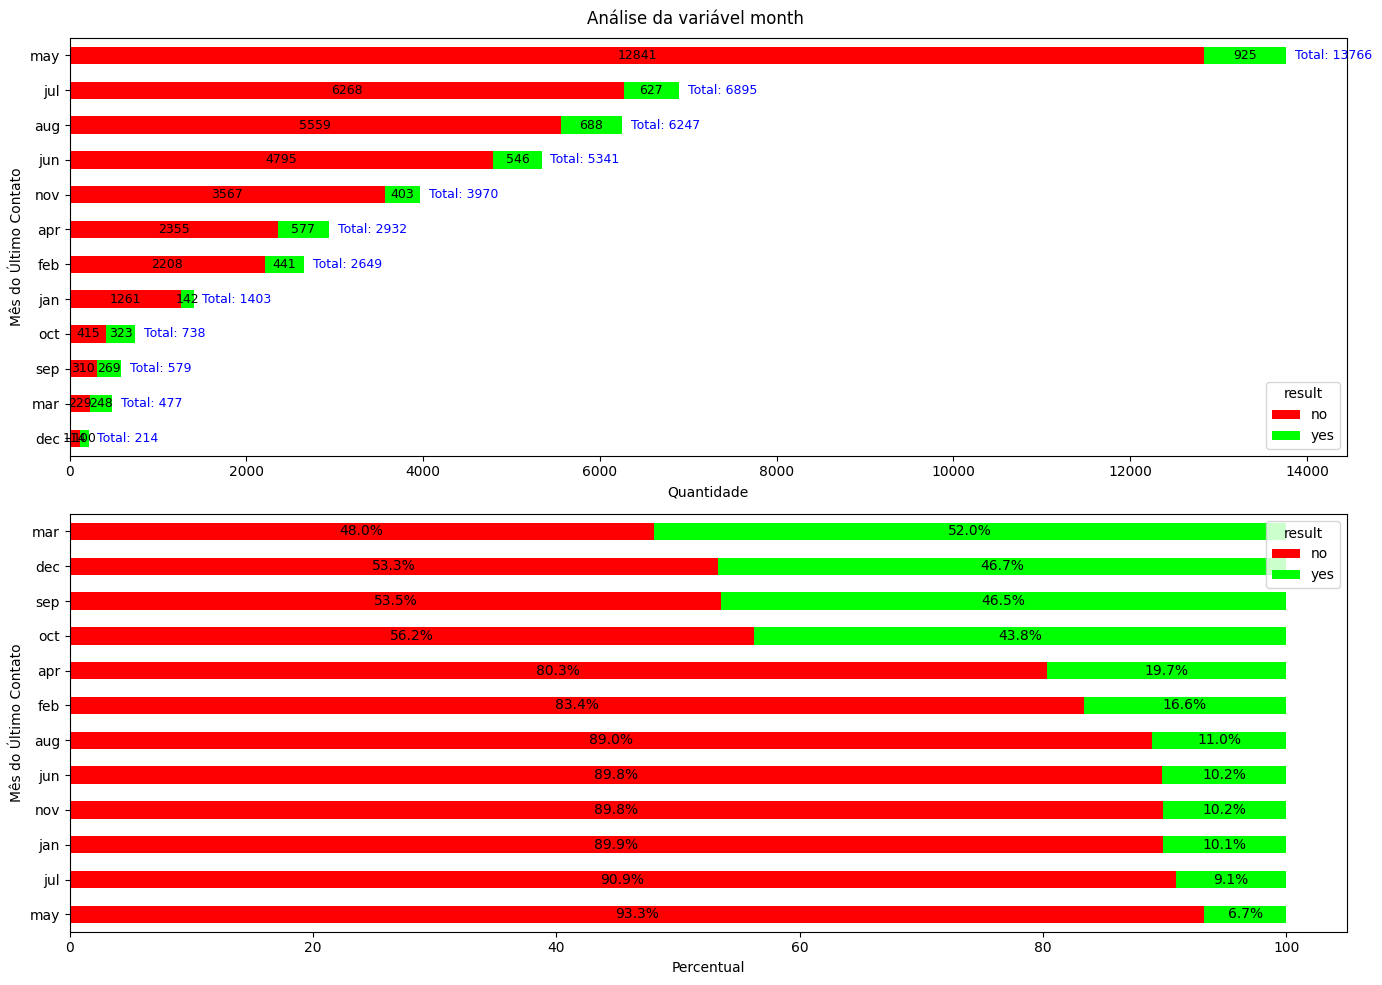

In [31]:
fig, ax = plt.subplots(2,1, figsize = (14, 10))
fig.suptitle('Análise da variável month')

# plot 1
# Preparação do df
df_group = df.groupby(['month', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('month', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='month', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get)

# plot
df_pivot.plot(kind='barh', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Quantidade')
ax[0].set_ylabel('Mês do Último Contato')

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(no/2, i, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(no + yes/2, i, f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(no+yes+100, i, f"Total: {no+yes}", va='center', ha='left', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('month', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='month', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=True)

# plot
df_pivot.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Percentual')
ax[1].set_ylabel('Mês do Último Contato')

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(no/2, i, f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [32]:
print("Valores nulos:", df['month'].isnull().sum())

Valores nulos: 0


O mês de maio foi o mês com a maior quantidade de contatos realizados. No entato, em termos percentuais foi o mês com a menor taxa de aceitação da campanha.

A diferença entre o 1º e o 2º mês de maior contato é extremamente grande. O segundo mês possui praticamente a metade do total de contatos realizados no primeiro mês. Isso é mais um indicativo de desbalanceamento do dataset.

Curiosamente os mêses com menor atividade foram os meses com maior percentual de conversão (março, dezembor, setembro e outubro).

Por fim, não há presença de registros nulos.

 ### duration (duração da ligação)

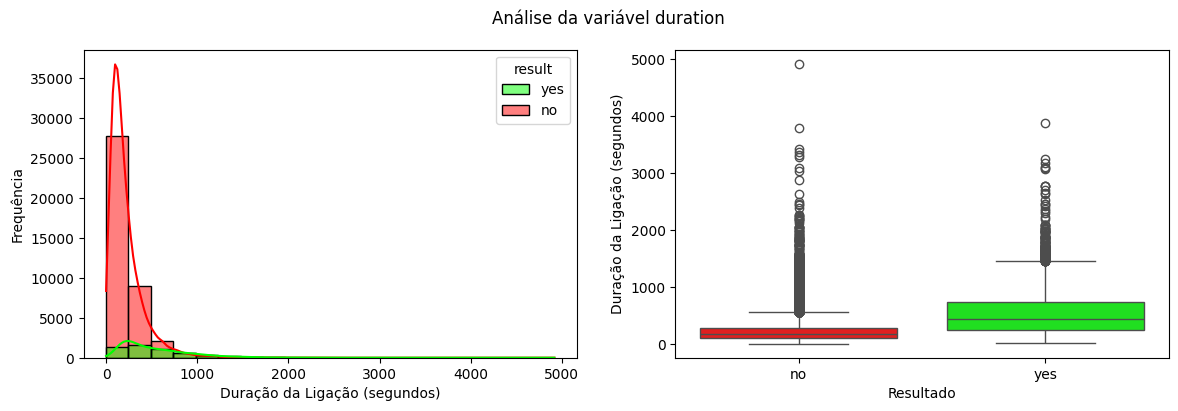

In [33]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável duration')

sns.histplot(data=df, kde=True, bins=20, x='duration', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Duração da Ligação (segundos)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='duration', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Duração da Ligação (segundos)')
plt.show()

In [34]:
print("Valores nulos:", df['duration'].isnull().sum())

Valores nulos: 0


O histograma indica uma distribuição assimétrica à direita, com presença de possíveis outliers em chamadas superiores a 80 minutos. Esses valores extremos, somados ao desbalanceamento do dataset, dificultam uma análise mais robusta dessa variável.

Como descrito na documentação, a duração da chamada influencia diretamente o resultado da campanha: contatos nulos ou muito curtos tendem a gerar insucesso, enquanto chamadas mais longas estão associadas a maior taxa de sucesso, como evidenciado no boxplot.

Dada a forte correlação com a variável alvo, a duração da chamada não será utilizada em modelos preditivos, para evitar viés. No entanto, ela permanece relevante em análises exploratórias, pois ajuda a compreender o comportamento dos clientes durante a campanha.

Por fim, não foram encontrados valores nulos.

### campaign (número de contatos realizados na campanha)

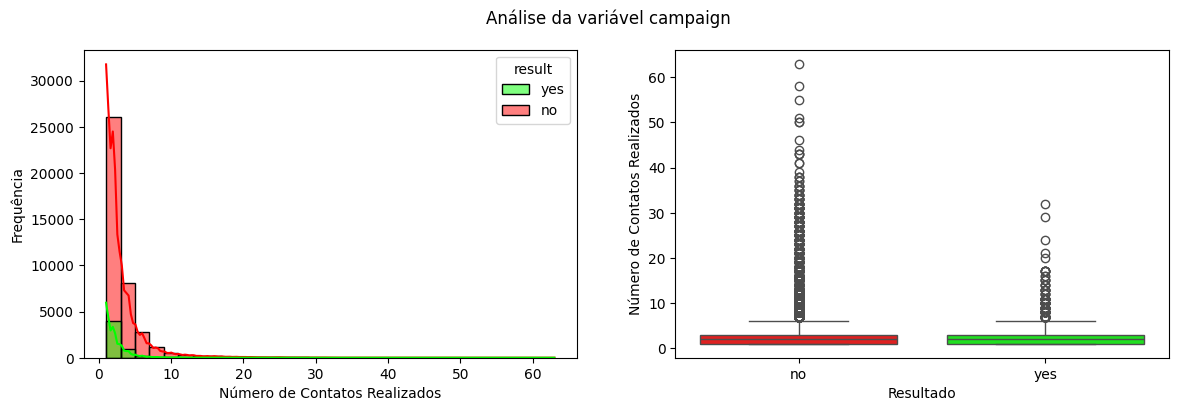

In [35]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável campaign')

sns.histplot(data=df, kde=True, binwidth=2, x='campaign', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Número de Contatos Realizados')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='campaign', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Número de Contatos Realizados')

plt.show()

In [36]:
print("Valores nulos:", df['campaign'].isnull().sum())

Valores nulos: 0


A variável foi discretizada em faixas de largura 2 para facilitar a visualização. Observa-se que a maioria dos clientes recebeu entre 2 e 10 contatos, enquanto um número ínfimo chegou a ser contactado até 63 vezes, caracterizando outliers que dificultam a interpretação da distribuição.

O boxplot indica que a quantidade de contatos não exerce influência significativa sobre o resultado da campanha, embora haja maior concentração de outliers associados a insucessos.

Por fim, não foram identificados valores nulos nesta variável, o que reforça a consistência dos dados.

### pdays (número de dias desde o último contato)

In [37]:
df.groupby(['pdays', 'result'], as_index=False).size().iloc[0:10]

,pdays,result,size
0,-1,no,33570
1,-1,yes,3384
2,1,no,9
3,1,yes,6
4,2,no,35
5,2,yes,2
6,3,no,1
7,4,no,1
8,4,yes,1
9,5,no,11


Observa-se que a grande maioria dos clientes foram contactados pela primeira vez (36.954, cerca de 81%).

In [38]:
df.groupby(['pdays', 'result'], as_index=False).size().iloc[-10:]

,pdays,result,size
904,805,yes,1
905,808,no,1
906,826,no,1
907,828,yes,1
908,831,no,1
909,838,no,1
910,842,yes,1
911,850,no,1
912,854,yes,1
913,871,no,1


Além disso, dentre os que foram contatados mais de uma vez, alguns apresentam um espaço de tempo muito longo, chegando até 871 dias (mais de dois anos e meio).

In [39]:
print("Valores nulos:", df['pdays'].isnull().sum())

Valores nulos: 0


Não há registros em que essa informação não foi informada.

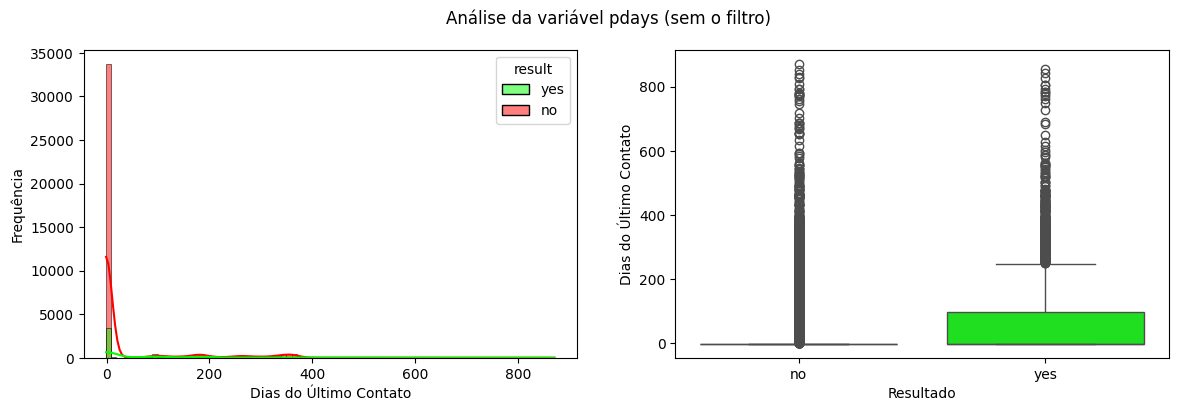

In [40]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável pdays (sem o filtro)')

sns.histplot(data=df, kde=True, binwidth=10, x='pdays', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Dias do Último Contato')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='pdays', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Dias do Último Contato')

plt.show()

Ao tentar analisar os dados brutos, o desbalanceamento entre clientes que nunca foram contactados durante a campanha e os que já foram contactados afeta a visualização da distribuição. Desse modo iremos analisar os registros separadamente: valores maiores que 0 (que foram contactados mais de uma vez) e menores que 0 (que foram contactados pela primeira vez).

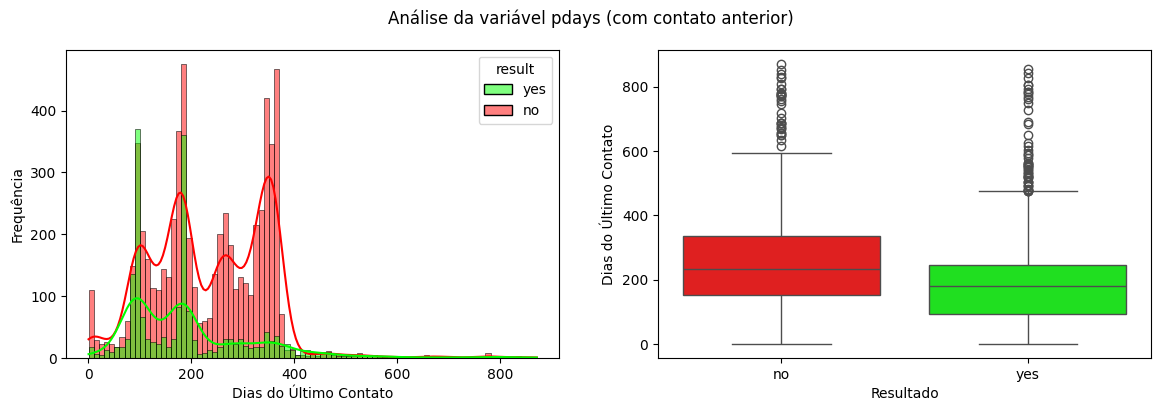

In [41]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável pdays (com contato anterior)')

sns.histplot(data=df[df.pdays > 0], kde=True, binwidth=10, x='pdays', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Dias do Último Contato')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='pdays', data=df[df.pdays > 0], hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Dias do Último Contato')

plt.show()

Observa-se uma distribuição multimodal. Além disso, nota-se que até 200 dias de folga, o comportamento das linhas do resultado são semelhantes, e em alguns momentos, o resultado positivo chega a superar o resultado negativo. Após 200 dias, a linha de sucesso praticamente não cresce mais, e as tentativas de contato, quase sempre resultaram em fracasso.

O gráfico boxplot demonstra um pouco esse comportamento, com a maioria dos casos de sucesso estarem antes dos 200 dias. Como visto anteriormente, há alguns registros extremos (com mais de 800 dias de contato) que devem ser analisados separadamente.

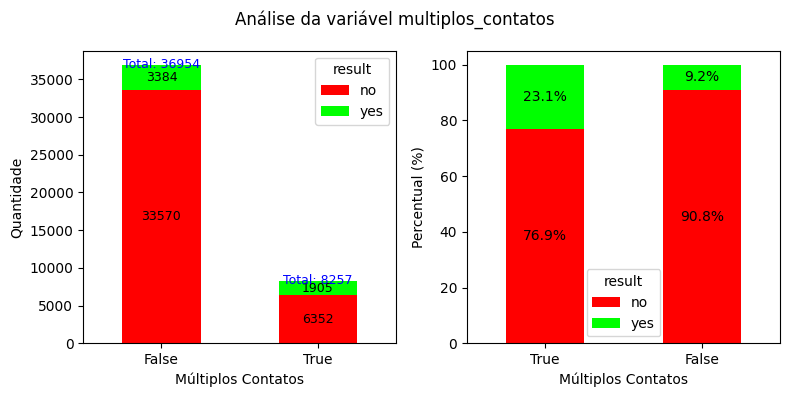

In [68]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
fig.suptitle('Análise da variável multiplos_contatos')

# Preparação do df
df['multiplos_contatos'] = df['pdays'] > 0
df_group = df.groupby(['multiplos_contatos','result'], as_index=False).size()
df_group['total'] = df_group.groupby('multiplos_contatos')['size'].transform('sum')

# Pivot absoluto
df_pivot = df_group.pivot(index='multiplos_contatos', columns='result', values='size').fillna(0)
df_pivot = df_pivot.assign(total=df_pivot.sum(axis=1)).sort_values(by="total", ascending=False)

# Plot 1 - valores absolutos
df_pivot[['no','yes']].plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Múltiplos Contatos')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

for i,(no,yes) in enumerate(zip(df_pivot['no'],df_pivot['yes'])):
    ax[0].text(i,no/2,f"{no}",va='center',ha='center',fontsize=9)
    ax[0].text(i,no+yes/2,f"{yes}",va='center',ha='center',fontsize=9)
    ax[0].text(i,no+yes+50,f"Total: {no+yes}",va='center',ha='center',fontsize=9,color='blue')

# Pivot percentual
df_group['percent'] = df_group.groupby('multiplos_contatos')['size'].transform(lambda x: x/x.sum()*100)
df_pivot = df_group.pivot(index='multiplos_contatos', columns='result', values='percent').fillna(0)
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# Plot 2 - percentuais
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000','#00ff00'])
ax[1].set_xlabel('Múltiplos Contatos')
ax[1].set_ylabel('Percentual (%)')
ax[1].tick_params(axis='x', labelrotation=0)

for i,(no,yes) in enumerate(zip(df_pivot['no'],df_pivot['yes'])):
    ax[1].text(i,no/2,f"{no:.1f}%",va='center',ha='center',fontsize=10)
    ax[1].text(i,no+yes/2,f"{yes:.1f}%",va='center',ha='center',fontsize=10)

plt.tight_layout()
plt.show()


Embora haja uma diferença significativa entre registros que foram contactados anteriormente (8257) e os que não foram (36954). Observa-se que o percentual de aceitação foi maior entre os que foram contactados mais de uma vez e os que foram contactados apenas uma vez.

Uma proposta de tratamento desta variável, seria discretizar as informações em faixas de valores, como "primeiro contato", "até 10 dias de folga", "até 20 dias de folga", etc.

### previous (número de contatos realizados antes desta campanha)

Análise inicial dos valores desta variável:

In [44]:
df.groupby(['previous', 'result'], as_index=False).size().iloc[0:10]

,previous,result,size
0,0,no,33570
1,0,yes,3384
2,1,no,2189
3,1,yes,583
4,2,no,1650
5,2,yes,456
6,3,no,848
7,3,yes,294
8,4,no,543
9,4,yes,171


Há uma grande quantidade de clientes que foram contactados apenas nesta campanha (36.954, cerca de 81%). Coincidentemente, esse valor é igual ao valor de clientes que foram contactados uma única vez na campanha (variável anterior - pdays).

In [51]:
df.groupby(['previous', 'result'], as_index=False).size().iloc[-10:]

,previous,result,size
56,32,no,1
57,35,no,1
58,37,no,2
59,38,no,2
60,40,no,1
61,41,no,1
62,51,no,1
63,55,yes,1
64,58,yes,1
65,275,no,1


Embora seja parecida com a variável anterior, aparenta ter menos valores extremos.

In [52]:
print("Valores nulos:", df['previous'].isnull().sum())

Valores nulos: 0


Não há registros nulos.

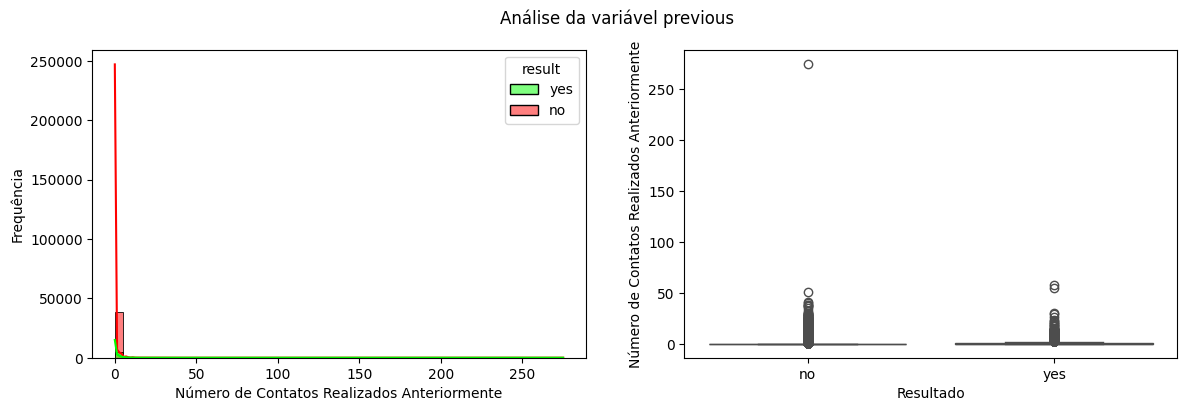

In [45]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável previous')

sns.histplot(data=df, kde=True, binwidth=5, x='previous', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Número de Contatos Realizados Anteriormente')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='previous', data=df, hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Número de Contatos Realizados Anteriormente')
plt.show()

Da mesma forma que a variável pdays, a grande quantidade de registros de clientes que nunca foram contactados em campanhas anteriores prejudica a análise mais adequada da distribuição dos registros. Desse modo, novamente, iremos dividir a análise entre os que foram contactados em campanhas anteriores e os que foram contactados apenas na campanha atual.

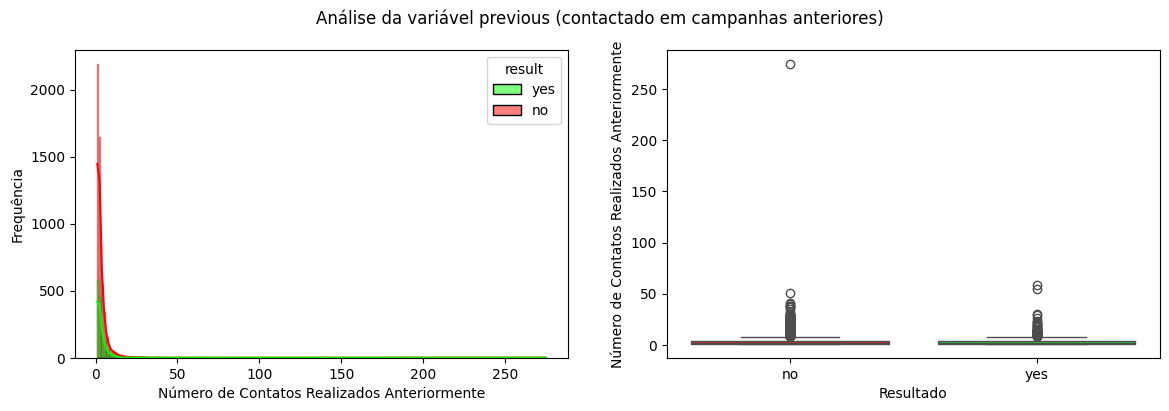

In [66]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável previous (contactado em campanhas anteriores)')

sns.histplot(data=df[(df.previous > 0)], kde=True, binwidth=1, x='previous', hue="result", palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
ax[0].set_xlabel('Número de Contatos Realizados Anteriormente')
ax[0].set_ylabel('Frequência')

sns.boxplot(x='result', y='previous', data=df[(df.previous > 0)], hue='result', palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
ax[1].set_xlabel('Resultado')
ax[1].set_ylabel('Número de Contatos Realizados Anteriormente')

plt.show()

Após a remoção dos registros dos que nunca foram contactados em campanhas anteriores, a distibuição ainda permanece assimétrica a direita. Devido a presença de alguns valores extremos, ainda não é possível visualizar tão bem a distribuição. Após o tratamento de outliers poderemos analisar melhor o resultado.

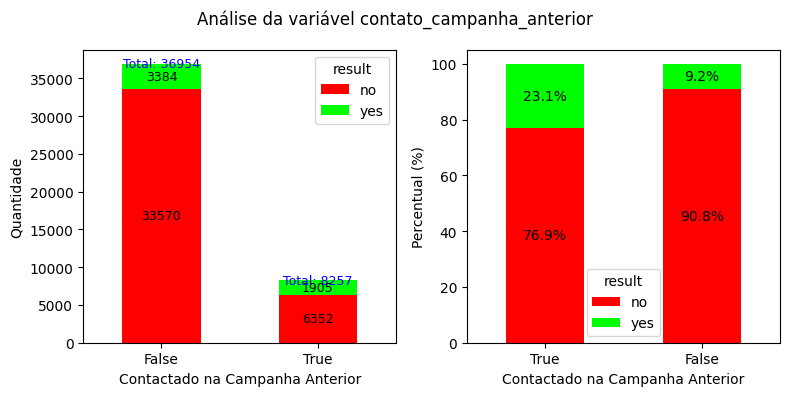

In [70]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
fig.suptitle('Análise da variável contato_campanha_anterior')

# Preparação do df
df['contato_campanha_anterior'] = df['previous'] > 0
df_group = df.groupby(['contato_campanha_anterior','result'], as_index=False).size()
df_group['total'] = df_group.groupby('contato_campanha_anterior')['size'].transform('sum')

# Pivot absoluto
df_pivot = df_group.pivot(index='contato_campanha_anterior', columns='result', values='size').fillna(0)
df_pivot = df_pivot.assign(total=df_pivot.sum(axis=1)).sort_values(by="total", ascending=False)

# Plot 1 - valores absolutos
df_pivot[['no','yes']].plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Contactado na Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

for i,(no,yes) in enumerate(zip(df_pivot['no'],df_pivot['yes'])):
    ax[0].text(i,no/2,f"{no}",va='center',ha='center',fontsize=9)
    ax[0].text(i,no+yes/2,f"{yes}",va='center',ha='center',fontsize=9)
    ax[0].text(i,no+yes+50,f"Total: {no+yes}",va='center',ha='center',fontsize=9,color='blue')

# Pivot percentual
df_group['percent'] = df_group.groupby('contato_campanha_anterior')['size'].transform(lambda x: x/x.sum()*100)
df_pivot = df_group.pivot(index='contato_campanha_anterior', columns='result', values='percent').fillna(0)
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# Plot 2 - percentuais
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000','#00ff00'])
ax[1].set_xlabel('Contactado na Campanha Anterior')
ax[1].set_ylabel('Percentual (%)')
ax[1].tick_params(axis='x', labelrotation=0)

for i,(no,yes) in enumerate(zip(df_pivot['no'],df_pivot['yes'])):
    ax[1].text(i,no/2,f"{no:.1f}%",va='center',ha='center',fontsize=10)
    ax[1].text(i,no+yes/2,f"{yes:.1f}%",va='center',ha='center',fontsize=10)

plt.tight_layout()
plt.show()


Curiosamente, até o percentual de aceitação entre os que foram contactados na campanha anterior e os que não foram, foi igual ao resultado da variável anterior (pdays - dias de folga). Mas como mostramos no gráfico anterior, elas não são iguais, pois possuem distribuições diferentes. Assim, observando os gráficos acima, embora a diferença entre os que foram contactados em campanhas anteriores e os que não foram seja grande, podemos considerar, olhando para os percentuais apresentados, que os clientes que foram contactados em campanhas  anteriores, aderiram melhor a campanha.

### poutcome (resultado da campanha anterior)

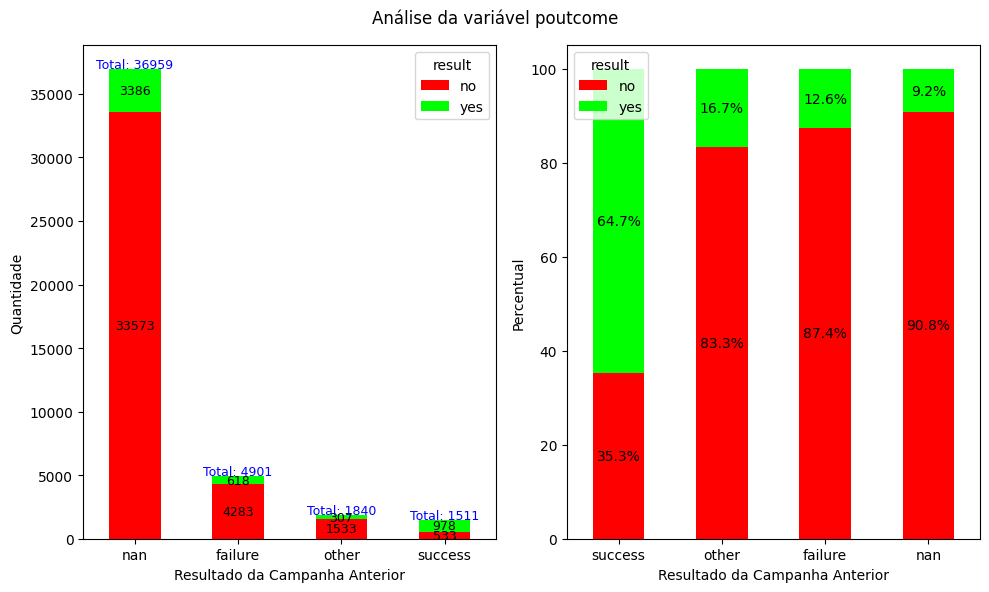

In [47]:
fig, ax = plt.subplots(1,2, figsize = (10, 6))
fig.suptitle('Análise da variável poutcome')

# plot 1
# Preparação do df
df_group = df.groupby(['poutcome', 'result'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('poutcome', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='poutcome', columns='result', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[['yes', 'no']].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Resultado da Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('poutcome', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='poutcome', columns='result', values='percent')
df_pivot = df_pivot.sort_values(by="yes", ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Resultado da Campanha Anterior')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [48]:
print("Valores nulos:", df['poutcome'].isnull().sum())

Valores nulos: 36959


Esta variável possui o maior déficit de informações: 36959 registros nulos. No entanto, como visto na variável anterior (previous), 36954 registros não foram contatados em campanhas anteriores, o que pode responder o motivo dessa variável possuir tantos valores nulos. Na etapa de pré-processamento, poderemos analisar se isso é verdadeiro, e criar uma nova categoria para esses registros, como "N/A", ou considerar utilizar o valor 'other'.

Analisando apenas o resultado dos valores não nulo ('failure', 'other' e 'sucess') podemos perceber duas coisas relevantes:
- Dentre as pessoas que aderiram à campanha anterior (sucess), a quantidade pessoas que também aderiram a campanha atual foi maior do que os que não aderiram;
- Dentre as pessoas que recusaram a campanha anterior, a grande maioria também recusou a campanha atual.

Isso mostra que o produto pode ter sido bem apreciado por quem experimentou, mas dificilmente os clientes são convencidos de que é um bom produto.

Por fim, observa-se que não há presença de valores nulos.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Para analisar a correlação entre as variáveis, iremos adicionar uma nova coluna ao dataframe, convertendo a variável alvo 'result' em uma variável efetivamente binária. Ou seja, o valor 'yes' se tornará 1 e o valor 'no' se tornará 0.

In [78]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df['result_num'] = df['result'].map({'yes': 1, 'no': 0})
variaveis_numericas = [
    'age',
    'balance',
    'day_of_week',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'result_num'
]
df[variaveis_numericas].corr()


Matriz de Correlação:


,age,balance,day_of_week,duration,campaign,pdays,previous,result_num
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838
day_of_week,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,0.093236
result_num,0.025155,0.052838,-0.028348,0.394521,-0.073172,0.103621,0.093236,1.000000


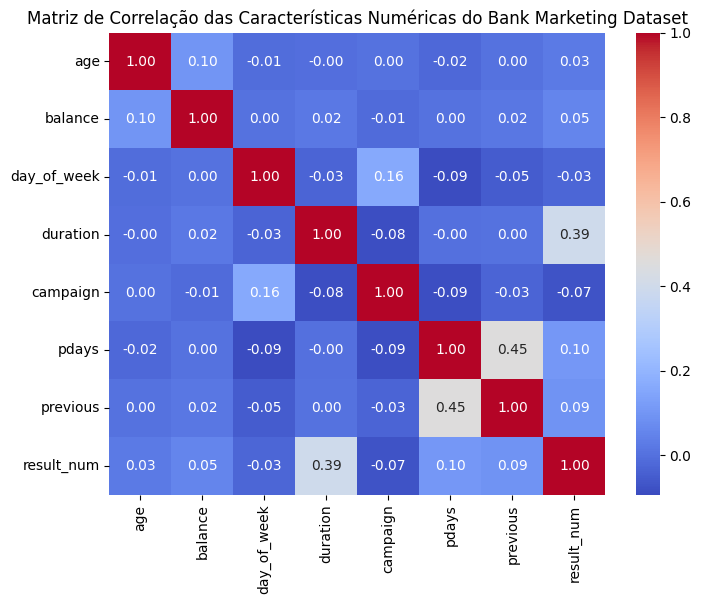

In [79]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Bank Marketing Dataset')
plt.show()

Observando o mapa de calor, praticamente todas as variáveis são pouco correlacionadas. As que tem um grau maior de correlação são 'previous' e 'pdays', e 'duration' e 'result_num'.

Conforme indicado na própria documentação do dataset, a variável 'duration' possui forte relação com o resultado da campanha, já que uma duração igual a 0 ou próximo disso, dificilmente gera um resultado positivo.

Já as variáveis 'pdays' (dias do último contato) e 'previous' (contatos realizados na última campanha) possuem uma correlação mais alta, devido ao grande número de registros que foram contactados apenas uma vez na campanha atual e que nunca foram contactados em campanhas anteriores. A variável 'pdays' representa esses registros como -1, e a variável 'previous' representa esses registros como 0. Mas além dessa semelhança, essas variáveis não são correlacionadas.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.